# Multi-Teacher Feature Extraction + Neural Classifiers (PyTorch)
This notebook extracts features from **BERT**, **RoBERTa**, and **DistilBERT** and trains a separate neural classifier for each feature set using model-specific configurations with detailed metric tracking.

In [1]:
# selected_models = ["gpt2", "google-t5/t5-base", "answerdotai/ModernBERT-base", "jhu-clsp/ettin-decoder-17m"]
selected_models = ["jhu-clsp/ettin-decoder-17m"]

## 1. Environment Setup

In [30]:
import os
import time
import random
import copy
import json
from dataclasses import dataclass
from datetime import timedelta

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F

from transformers import AutoTokenizer, AutoModel
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [35]:
config_path = os.path.join(os.getcwd(), "grid_search_config.json")
with open(config_path, "r", encoding="utf-8") as f:
    config = json.load(f)

SEED = int(config["seed"])
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

training_config = config.get("training", {})
GRAD_CLIP = float(training_config.get("gradient_clip_norm", 1.0))
MIN_DELTA = float(training_config.get("min_delta", 0.0))
OPTIMIZER_NAME = str(training_config.get("optimizer", "Adam"))

feature_config = config.get("feature_extraction", {})
FEATURE_BATCH_SIZE = int(feature_config.get("batch_size", 32))
FEATURE_MAX_LENGTH = int(feature_config.get("max_length", 256))

LATENCY_BATCH_SIZE = int(config.get("evaluation", {}).get("latency_batch_size", 256))

# Load distillation configuration
distillation_config = config.get("distillation", {})
DISTILLATION_ENABLED = distillation_config.get("enabled", False)
DISTILLATION_ALPHA = float(distillation_config.get("alpha", 0.5))
DISTILLATION_TEMPERATURE = float(distillation_config.get("temperature", 1.0))

student_config = distillation_config.get("student_config", {})
STUDENT_HIDDEN_DIMS = student_config.get("hidden_dims", [256, 128])
STUDENT_DROPOUT = float(student_config.get("dropout", 0.3))
STUDENT_LR = float(student_config.get("learning_rate", 0.001))
STUDENT_BATCH_SIZE = int(student_config.get("batch_size", 64))
STUDENT_EPOCHS = int(student_config.get("epochs", 50))
STUDENT_PATIENCE = int(student_config.get("patience", 10))
DISTILLATION_OUTPUT_DIR = distillation_config.get("output_dir", "distillation_metrics")

# Filter models based on selected_models (model_id list).
selected_model_entries = []
for selected_model_id in selected_models:
    for model_entry in config.get("models", []):
        if model_entry["model_id"] == selected_model_id:
            selected_model_entries.append(model_entry)
            break

selected_model_names = [m["name"] for m in selected_model_entries]

# Load only model-specific configurations for selected models.
all_model_configs = config.get("model_config", {})
model_configs = {name: all_model_configs[name] for name in selected_model_names}

print("Using selected models:")
for m in selected_model_entries:
    print(f"  {m['name']} ({m['model_id']})")

print("\nLoaded filtered model-specific configurations:")
for model_name, model_cfg in model_configs.items():
    print(f"  {model_name}: {model_cfg}")

if DISTILLATION_ENABLED:
    print("\nDistillation configuration loaded:")
    print(f"  Alpha: {DISTILLATION_ALPHA}")
    print(f"  Temperature: {DISTILLATION_TEMPERATURE}")
    print(f"  Student Config: hidden_dims={STUDENT_HIDDEN_DIMS}, dropout={STUDENT_DROPOUT}, lr={STUDENT_LR}")
    print(f"  Training: batch_size={STUDENT_BATCH_SIZE}, epochs={STUDENT_EPOCHS}, patience={STUDENT_PATIENCE}")


Using selected models:
  EttinDecoder (jhu-clsp/ettin-decoder-17m)

Loaded filtered model-specific configurations:
  EttinDecoder: {'epochs_options': [200], 'batch_size_options': [128], 'hidden_dims_options': [[512, 256, 128, 64]], 'dropout_options': [0.1], 'lr_options': [5e-05], 'n_splits': 5, 'patience': 10, 'show_epoch_progress': True}

Distillation configuration loaded:
  Alpha: 0.5
  Temperature: 1.0
  Student Config: hidden_dims=[256, 128, 64, 32], dropout=0.1, lr=5e-05
  Training: batch_size=64, epochs=200, patience=10


## 2. GPU Availability

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("CUDA available:", torch.cuda.is_available())
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA version:", torch.version.cuda)

CUDA available: True
Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
CUDA version: 12.4


## 3. Load Multiclass Sentiment Dataset (JSONL)

In [5]:
data_path = os.path.join(os.getcwd(), config["data"]["data_file"])
df = pd.read_json(data_path, lines=True)
df["label"] = df["label"].astype(int)
df.head()

,id,text,label,sentiment
0,9536,"Cooking microwave pizzas, yummy",2,positive
1,6135,Any plans of allowing sub tasks to show up in ...,1,neutral
2,17697,"I love the humor, I just reworded it. Like sa...",2,positive
3,14182,naw idk what ur talkin about,1,neutral
4,17840,That sucks to hear. I hate days like that,0,negative


## 4. Train/Validation/Test Split

In [7]:
texts = df["text"].astype(str).to_numpy()
labels = df["label"].to_numpy()

test_size = config["data"]["test_size"]
val_split = config["data"]["val_split"]

x_train, x_temp, y_train, y_temp = train_test_split(
    texts, labels, test_size=test_size, random_state=SEED, stratify=labels
)
x_val, x_test, y_val, y_test = train_test_split(
    x_temp, y_temp, test_size=val_split, random_state=SEED, stratify=y_temp
)

num_classes = len(np.unique(labels))
print(f"Train: {len(x_train)}, Val: {len(x_val)}, Test: {len(x_test)}")
print(f"Number of classes: {num_classes}")

Train: 21984, Val: 2748, Test: 2749
Number of classes: 3


## 5. Feature Extraction with Transformer Encoders

In [8]:
notebook_start_time = time.perf_counter()

In [9]:
@dataclass
class ModelSpec:
    name: str
    model_id: str

class TextDataset(Dataset):
    def __init__(self, texts, labels=None):
        self.texts = texts
        self.labels = labels

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        if self.labels is None:
            return self.texts[idx]
        return self.texts[idx], int(self.labels[idx])

In [10]:
def make_text_loader(texts, labels=None, batch_size=32):
    ds = TextDataset(texts, labels)
    return DataLoader(ds, batch_size=batch_size, shuffle=False)


def prepare_tokenizer_and_model(model_id):
    tokenizer = AutoTokenizer.from_pretrained(model_id)
    model = AutoModel.from_pretrained(model_id).to(device)

    if tokenizer.pad_token is None:
        fallback_token = tokenizer.eos_token or tokenizer.sep_token or tokenizer.unk_token
        if fallback_token is not None:
            tokenizer.pad_token = fallback_token
        else:
            tokenizer.add_special_tokens({"pad_token": "[PAD]"})
            model.resize_token_embeddings(len(tokenizer))

    model.config.pad_token_id = tokenizer.pad_token_id
    return tokenizer, model


def extract_features(model_id, texts, batch_size=32, max_length=256):
    """Extract CLS or pooled features using a transformer encoder."""
    tokenizer, model = prepare_tokenizer_and_model(model_id)
    model.eval()

    features = []
    loader = make_text_loader(texts, batch_size=batch_size)
    with torch.no_grad():
        for batch_texts in loader:
            encoded = tokenizer(
                list(batch_texts),
                max_length=max_length,
                padding=True,
                truncation=True,
                return_tensors="pt"
            ).to(device)

            outputs = model(**encoded)
            if hasattr(outputs, "pooler_output") and outputs.pooler_output is not None:
                batch_features = outputs.pooler_output
            else:
                batch_features = outputs.last_hidden_state[:, 0, :]

            features.append(batch_features.detach().cpu())

    features = torch.cat(features, dim=0)
    return features

model_specs = [ModelSpec(m["name"], m["model_id"]) for m in selected_model_entries]
feature_cache = {}

In [11]:
for spec in model_specs:
    print(f"=========Extracting features with {spec.name}...")
    feature_cache[spec.name] = {
        "train": extract_features(
            spec.model_id,
            x_train,
            batch_size=FEATURE_BATCH_SIZE,
            max_length=FEATURE_MAX_LENGTH,
        ),
        "val": extract_features(
            spec.model_id,
            x_val,
            batch_size=FEATURE_BATCH_SIZE,
            max_length=FEATURE_MAX_LENGTH,
        ),
        "test": extract_features(
            spec.model_id,
            x_test,
            batch_size=FEATURE_BATCH_SIZE,
            max_length=FEATURE_MAX_LENGTH,
        ),
    }
    print(f"{spec.name} train feature shape: {feature_cache[spec.name]['train'].shape}")
    print(f"{spec.name} val feature shape: {feature_cache[spec.name]['val'].shape}")
    print(f"{spec.name} test feature shape: {feature_cache[spec.name]['test'].shape}")

=========Extracting features with EttinDecoder...


Loading weights:   0%|          | 0/58 [00:00<?, ?it/s]

ModernBertDecoderModel LOAD REPORT from: jhu-clsp/ettin-decoder-17m
Key                  | Status     |  | 
---------------------+------------+--+-
lm_head.norm.weight  | UNEXPECTED |  | 
decoder.bias         | UNEXPECTED |  | 
lm_head.dense.weight | UNEXPECTED |  | 
decoder.weight       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/58 [00:00<?, ?it/s]

ModernBertDecoderModel LOAD REPORT from: jhu-clsp/ettin-decoder-17m
Key                  | Status     |  | 
---------------------+------------+--+-
lm_head.norm.weight  | UNEXPECTED |  | 
decoder.bias         | UNEXPECTED |  | 
lm_head.dense.weight | UNEXPECTED |  | 
decoder.weight       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/58 [00:00<?, ?it/s]

ModernBertDecoderModel LOAD REPORT from: jhu-clsp/ettin-decoder-17m
Key                  | Status     |  | 
---------------------+------------+--+-
lm_head.norm.weight  | UNEXPECTED |  | 
decoder.bias         | UNEXPECTED |  | 
lm_head.dense.weight | UNEXPECTED |  | 
decoder.weight       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


EttinDecoder train feature shape: torch.Size([21984, 256])
EttinDecoder val feature shape: torch.Size([2748, 256])
EttinDecoder test feature shape: torch.Size([2749, 256])


## 6. Neural Classifier Architecture

In [12]:
class FeatureClassifier(nn.Module):
    """MLP for fixed-size transformer features."""
    def __init__(self, input_dim, num_classes, hidden_dims, dropout=0.3):
        super().__init__()
        if not hidden_dims:
            raise ValueError("hidden_dims must contain at least one layer size")

        layers = []
        dims = [input_dim] + list(hidden_dims)
        for idx in range(len(hidden_dims)):
            layers.append(nn.Linear(dims[idx], dims[idx + 1]))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
        layers.append(nn.Linear(hidden_dims[-1], num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

class FeatureDataset(Dataset):
    def __init__(self, features, labels):
        self.features = features
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.features[idx], int(self.labels[idx])

def make_feature_loader(features, labels, batch_size=64, shuffle=True):
    ds = FeatureDataset(features, labels)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

## 7. Detailed Metrics Tracking System

In [13]:
class MetricsTracker:
    """Track detailed training metrics for TensorBoard-style visualization."""
    
    def __init__(self, model_name: str):
        self.model_name = model_name
        self.history = {
            'epoch': [],
            'train_loss': [],
            'train_acc': [],
            'train_precision': [],
            'train_recall': [],
            'train_f1': [],
            'val_loss': [],
            'val_acc': [],
            'val_precision': [],
            'val_recall': [],
            'val_f1': [],
            'learning_rate': [],
            'epoch_time': []
        }
        
    def log_epoch(self, epoch: int, train_metrics: dict, val_metrics: dict, 
                  lr: float, epoch_time: float):
        """Log metrics for a single epoch."""
        self.history['epoch'].append(epoch)
        self.history['train_loss'].append(train_metrics['loss'])
        self.history['train_acc'].append(train_metrics['acc'])
        self.history['train_precision'].append(train_metrics['precision'])
        self.history['train_recall'].append(train_metrics['recall'])
        self.history['train_f1'].append(train_metrics['f1'])
        self.history['val_loss'].append(val_metrics['loss'])
        self.history['val_acc'].append(val_metrics['acc'])
        self.history['val_precision'].append(val_metrics['precision'])
        self.history['val_recall'].append(val_metrics['recall'])
        self.history['val_f1'].append(val_metrics['f1'])
        self.history['learning_rate'].append(lr)
        self.history['epoch_time'].append(epoch_time)
        
    def get_dataframe(self) -> pd.DataFrame:
        """Get history as DataFrame."""
        return pd.DataFrame(self.history)
    
    def save(self, filepath: str):
        """Save metrics to CSV."""
        df = self.get_dataframe()
        # df.to_csv(filepath, index=False)
        # print(f"Saved {self.model_name} training metrics to {filepath}")
        
    def plot_metrics(self, save_path: str = None):
        """Plot training metrics."""
        df = self.get_dataframe()
        
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        fig.suptitle(f'{self.model_name} Training Metrics', fontsize=16, fontweight='bold')
        
        # Loss plot
        axes[0, 0].plot(df['epoch'], df['train_loss'], label='Train Loss', marker='o')
        axes[0, 0].plot(df['epoch'], df['val_loss'], label='Val Loss', marker='s')
        axes[0, 0].set_xlabel('Epoch')
        axes[0, 0].set_ylabel('Loss')
        axes[0, 0].set_title('Loss')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)
        
        # Accuracy plot
        axes[0, 1].plot(df['epoch'], df['train_acc'], label='Train Accuracy', marker='o')
        axes[0, 1].plot(df['epoch'], df['val_acc'], label='Val Accuracy', marker='s')
        axes[0, 1].set_xlabel('Epoch')
        axes[0, 1].set_ylabel('Accuracy')
        axes[0, 1].set_title('Accuracy')
        axes[0, 1].legend()
        axes[0, 1].grid(True, alpha=0.3)
        
        # F1 Score plot
        axes[1, 0].plot(df['epoch'], df['train_f1'], label='Train F1', marker='o')
        axes[1, 0].plot(df['epoch'], df['val_f1'], label='Val F1', marker='s')
        axes[1, 0].set_xlabel('Epoch')
        axes[1, 0].set_ylabel('F1 Score')
        axes[1, 0].set_title('F1 Score')
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)
        
        # Precision & Recall plot
        axes[1, 1].plot(df['epoch'], df['train_precision'], label='Train Precision', marker='o', linestyle='--')
        axes[1, 1].plot(df['epoch'], df['val_precision'], label='Val Precision', marker='s', linestyle='--')
        axes[1, 1].plot(df['epoch'], df['train_recall'], label='Train Recall', marker='^', linestyle=':')
        axes[1, 1].plot(df['epoch'], df['val_recall'], label='Val Recall', marker='v', linestyle=':')
        axes[1, 1].set_xlabel('Epoch')
        axes[1, 1].set_ylabel('Score')
        axes[1, 1].set_title('Precision & Recall')
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        
        if save_path:
            # plt.savefig(save_path, dpi=300, bbox_inches='tight')
            # print(f"Saved {self.model_name} training plot to {save_path}")
            pass
        
        plt.show()

## 8. Training and Evaluation Utilities

In [14]:
def compute_detailed_metrics(all_preds, all_labels):
    """Compute accuracy, precision, recall, and F1."""
    acc = accuracy_score(all_labels, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average="weighted", zero_division=0
    )
    return {
        'acc': acc,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    all_preds = []
    all_labels = []
    
    for x_batch, y_batch in loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        optimizer.zero_grad()
        logits = model(x_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        if GRAD_CLIP > 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()
        total_loss += loss.item() * x_batch.size(0)
        all_preds.append(torch.argmax(logits, dim=1).detach().cpu())
        all_labels.append(y_batch.detach().cpu())
    
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    metrics = compute_detailed_metrics(all_preds, all_labels)
    metrics['loss'] = total_loss / len(loader.dataset)
    return metrics

def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            logits = model(x_batch)
            loss = criterion(logits, y_batch)
            total_loss += loss.item() * x_batch.size(0)
            all_preds.append(torch.argmax(logits, dim=1).detach().cpu())
            all_labels.append(y_batch.detach().cpu())
    
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    metrics = compute_detailed_metrics(all_preds, all_labels)
    metrics['loss'] = total_loss / len(loader.dataset)
    return metrics

def make_optimizer(model, lr):
    opt = OPTIMIZER_NAME.strip().lower()
    if opt == "adam":
        return torch.optim.Adam(model.parameters(), lr=lr)
    if opt == "adamw":
        return torch.optim.AdamW(model.parameters(), lr=lr)
    raise ValueError(f"Unsupported optimizer: {OPTIMIZER_NAME}")

def train_with_tracking(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    epochs,
    patience=5,
    min_delta=0.0,
    verbose=True,
    metrics_tracker=None
):
    """Train model with detailed metric tracking."""
    best_state = copy.deepcopy(model.state_dict())
    best_val_acc = -1.0
    epochs_since_improve = 0

    for epoch in range(1, epochs + 1):
        epoch_start = time.perf_counter()
        
        train_metrics = train_epoch(model, train_loader, optimizer, criterion)
        val_metrics = eval_epoch(model, val_loader, criterion)
        
        epoch_time = time.perf_counter() - epoch_start
        
        # Get current learning rate
        current_lr = optimizer.param_groups[0]['lr']
        
        # Log metrics
        if metrics_tracker:
            metrics_tracker.log_epoch(epoch, train_metrics, val_metrics, current_lr, epoch_time)
        
        if verbose:
            print(
                f"Epoch {epoch:3d}/{epochs} | "
                f"train_loss={train_metrics['loss']:.4f} train_acc={train_metrics['acc']:.4f} train_f1={train_metrics['f1']:.4f} | "
                f"val_loss={val_metrics['loss']:.4f} val_acc={val_metrics['acc']:.4f} val_f1={val_metrics['f1']:.4f} | "
                f"time={epoch_time:.2f}s"
            )

        if val_metrics['acc'] > best_val_acc + min_delta:
            best_val_acc = val_metrics['acc']
            best_state = copy.deepcopy(model.state_dict())
            epochs_since_improve = 0
        else:
            epochs_since_improve += 1
            if epochs_since_improve >= patience:
                if verbose:
                    print(f"Early stopping at epoch {epoch}")
                break

    return best_state, best_val_acc

def evaluate_model(model, loader):
    """Evaluate model and return all metrics."""
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch = x_batch.to(device)
            logits = model(x_batch)
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            all_preds.append(preds)
            all_labels.append(y_batch.numpy())
    
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    metrics = compute_detailed_metrics(all_preds, all_labels)
    return metrics

def measure_latency(model, features, labels, batch_size=256):
    """Measure inference latency."""
    model.eval()
    loader = make_feature_loader(features, labels, batch_size=batch_size, shuffle=False)
    with torch.no_grad():
        for x_batch, _ in loader:
            _ = model(x_batch.to(device))
            break
        start = time.perf_counter()
        total = 0
        for x_batch, _ in loader:
            _ = model(x_batch.to(device))
            total += x_batch.size(0)
        end = time.perf_counter()
    return (end - start) / max(total, 1) * 1000

## 9. Train Models with Model-Specific Configurations

In [15]:

# Create output directory for metrics and plots
metrics_dir = "training_metrics"
os.makedirs(metrics_dir, exist_ok=True)

all_metrics_trackers = {}
final_results = {}
trained_teacher_models = {}  # stores trained model objects for use in distillation


In [16]:

for spec in model_specs:
    model_name = spec.name
    print(f"\n{'='*80}")
    print(f"Training {model_name} with model-specific configuration")
    print(f"{'='*80}")
    
    # Get model-specific config
    if model_name not in model_configs:
        print(f"WARNING: No config found for {model_name}, skipping...")
        continue
    
    model_cfg = model_configs[model_name]
    
    # Extract hyperparameters (taking first element from each _options list)
    epochs = model_cfg["epochs_options"][0]
    batch_size = model_cfg["batch_size_options"][0]
    hidden_dims = model_cfg["hidden_dims_options"][0]
    dropout = model_cfg["dropout_options"][0]
    lr = model_cfg["lr_options"][0]
    patience = model_cfg.get("patience", 5)
    
    print(f"Configuration:")
    print(f"  Epochs: {epochs}")
    print(f"  Batch Size: {batch_size}")
    print(f"  Hidden Dims: {hidden_dims}")
    print(f"  Dropout: {dropout}")
    print(f"  Learning Rate: {lr}")
    print(f"  Patience: {patience}")
    print()
    
    # Get features
    train_feats = feature_cache[model_name]["train"]
    val_feats = feature_cache[model_name]["val"]
    test_feats = feature_cache[model_name]["test"]
    input_dim = train_feats.shape[1]
    
    # Create data loaders
    train_loader = make_feature_loader(train_feats, y_train, batch_size=batch_size, shuffle=True)
    val_loader = make_feature_loader(val_feats, y_val, batch_size=batch_size, shuffle=False)
    test_loader = make_feature_loader(test_feats, y_test, batch_size=batch_size, shuffle=False)
    
    # Initialize model
    model = FeatureClassifier(
        input_dim, num_classes, hidden_dims=hidden_dims, dropout=dropout
    ).to(device)
    
    optimizer = make_optimizer(model, lr=lr)
    criterion = nn.CrossEntropyLoss()
    
    # Initialize metrics tracker
    metrics_tracker = MetricsTracker(model_name)
    
    # Train model
    print(f"Training {model_name}...")
    training_start = time.perf_counter()
    
    best_state, best_val_acc = train_with_tracking(
        model,
        train_loader,
        val_loader,
        optimizer,
        criterion,
        epochs=epochs,
        patience=patience,
        min_delta=MIN_DELTA,
        verbose=True,
        metrics_tracker=metrics_tracker
    )
    
    training_time = time.perf_counter() - training_start
    
    # Load best model weights and store for distillation use
    model.load_state_dict(best_state)
    trained_teacher_models[model_name] = model
    
    # Evaluate on test set
    print(f"\nEvaluating {model_name} on test set...")
    test_metrics = evaluate_model(model, test_loader)
    
    # Measure latency
    latency_ms = measure_latency(model, test_feats, y_test, batch_size=LATENCY_BATCH_SIZE)
    
    # Calculate model size
    params = sum(p.numel() for p in model.parameters())
    size_mb = params * 4 / 1e6
    
    # Store metrics tracker
    all_metrics_trackers[model_name] = metrics_tracker
    
    # Save training history
    history_path = os.path.join(metrics_dir, f"{model_name}_training_history.csv")
    # metrics_tracker.save(history_path)
    
    # Store final results
    final_results[model_name] = {
        'config': {
            'epochs': epochs,
            'batch_size': batch_size,
            'hidden_dims': str(hidden_dims),
            'dropout': dropout,
            'lr': lr,
            'patience': patience
        },
        'best_val_acc': best_val_acc,
        'test_acc': test_metrics['acc'],
        'test_precision': test_metrics['precision'],
        'test_recall': test_metrics['recall'],
        'test_f1': test_metrics['f1'],
        'training_time_s': training_time,
        'params': params,
        'size_mb': size_mb,
        'latency_ms': latency_ms,
        'epochs_trained': len(metrics_tracker.history['epoch'])
    }
    
    print(f"\n{model_name} Results:")
    print(f"  Best Val Accuracy: {best_val_acc:.4f}")
    print(f"  Test Accuracy: {test_metrics['acc']:.4f}")
    print(f"  Test Precision: {test_metrics['precision']:.4f}")
    print(f"  Test Recall: {test_metrics['recall']:.4f}")
    print(f"  Test F1: {test_metrics['f1']:.4f}")
    print(f"  Training Time: {training_time:.2f}s")
    print(f"  Model Size: {size_mb:.2f} MB")
    print(f"  Latency: {latency_ms:.4f} ms")
    print(f"  Epochs Trained: {len(metrics_tracker.history['epoch'])}")


Training EttinDecoder with model-specific configuration
Configuration:
  Epochs: 200
  Batch Size: 128
  Hidden Dims: [512, 256, 128, 64]
  Dropout: 0.1
  Learning Rate: 5e-05
  Patience: 10

Training EttinDecoder...
Epoch   1/200 | train_loss=1.0934 train_acc=0.3787 train_f1=0.2332 | val_loss=1.0918 val_acc=0.3846 val_f1=0.2137 | time=1.44s
Epoch   2/200 | train_loss=1.0923 train_acc=0.3848 train_f1=0.2140 | val_loss=1.0917 val_acc=0.3846 val_f1=0.2137 | time=0.43s
Epoch   3/200 | train_loss=1.0922 train_acc=0.3848 train_f1=0.2139 | val_loss=1.0917 val_acc=0.3846 val_f1=0.2137 | time=0.53s
Epoch   4/200 | train_loss=1.0920 train_acc=0.3848 train_f1=0.2139 | val_loss=1.0918 val_acc=0.3846 val_f1=0.2137 | time=0.58s
Epoch   5/200 | train_loss=1.0919 train_acc=0.3848 train_f1=0.2139 | val_loss=1.0917 val_acc=0.3846 val_f1=0.2137 | time=0.58s
Epoch   6/200 | train_loss=1.0922 train_acc=0.3848 train_f1=0.2139 | val_loss=1.0919 val_acc=0.3846 val_f1=0.2137 | time=0.48s
Epoch   7/200 | trai

## 10. Visualize Training Metrics

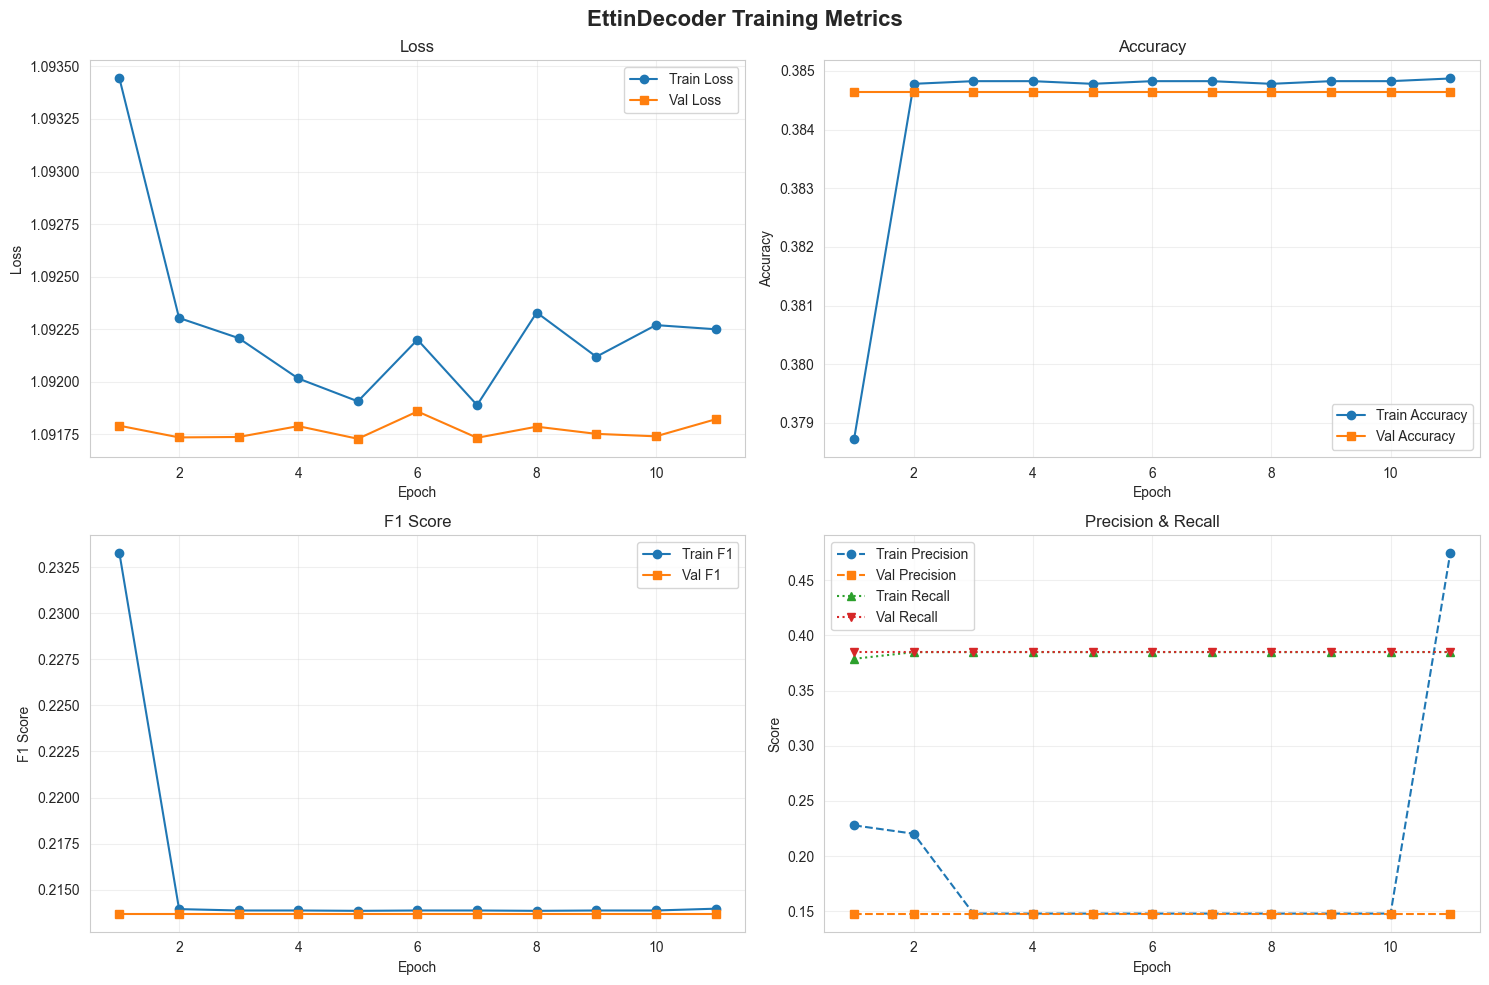

In [17]:
# Plot training metrics for each model
for model_name, tracker in all_metrics_trackers.items():
    plot_path = os.path.join(metrics_dir, f"{model_name}_training_plot.png")
    tracker.plot_metrics(save_path=plot_path)

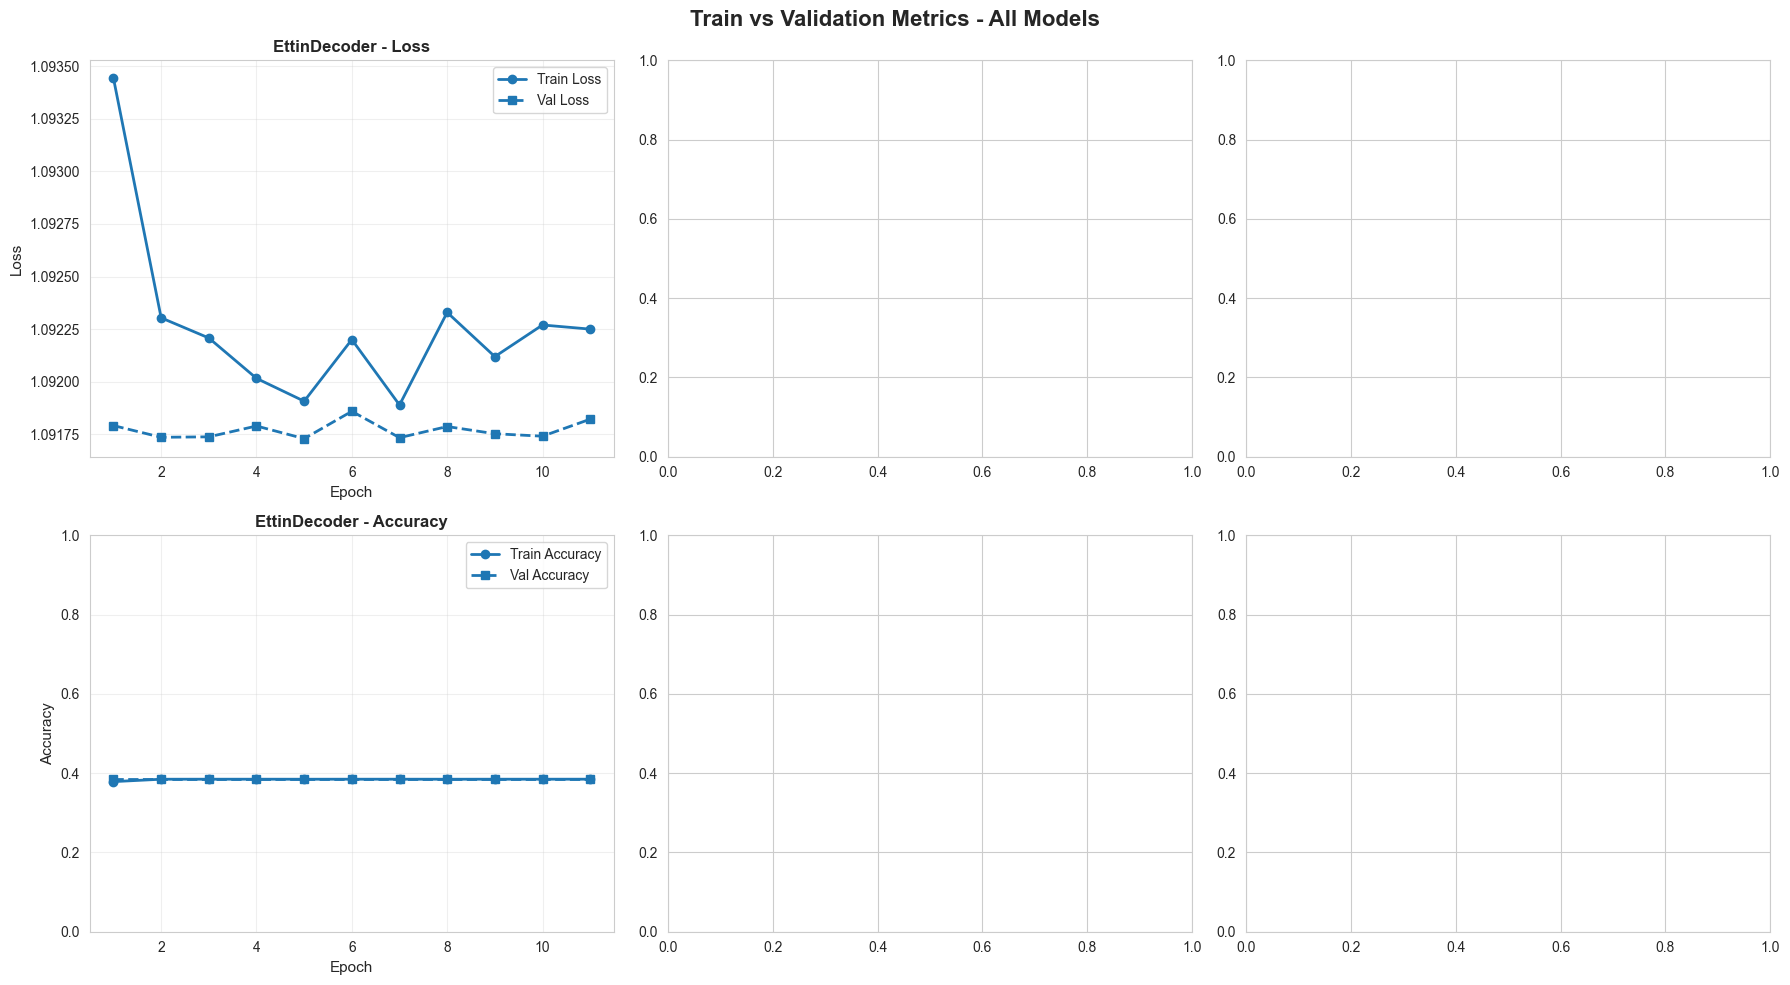

In [18]:
# Create train/val accuracy and loss curves for all models
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Train vs Validation Metrics - All Models', fontsize=16, fontweight='bold')

model_names = list(all_metrics_trackers.keys())
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for col_idx, model_name in enumerate(model_names):
    tracker = all_metrics_trackers[model_name]
    df = tracker.get_dataframe()
    
    # Loss plot
    axes[0, col_idx].plot(df['epoch'], df['train_loss'], label='Train Loss', marker='o', color=colors[col_idx], linestyle='-', linewidth=2)
    axes[0, col_idx].plot(df['epoch'], df['val_loss'], label='Val Loss', marker='s', color=colors[col_idx], linestyle='--', linewidth=2)
    axes[0, col_idx].set_xlabel('Epoch', fontsize=11)
    axes[0, col_idx].set_ylabel('Loss', fontsize=11)
    axes[0, col_idx].set_title(f'{model_name} - Loss', fontsize=12, fontweight='bold')
    axes[0, col_idx].legend(fontsize=10)
    axes[0, col_idx].grid(True, alpha=0.3)
    
    # Accuracy plot
    axes[1, col_idx].plot(df['epoch'], df['train_acc'], label='Train Accuracy', marker='o', color=colors[col_idx], linestyle='-', linewidth=2)
    axes[1, col_idx].plot(df['epoch'], df['val_acc'], label='Val Accuracy', marker='s', color=colors[col_idx], linestyle='--', linewidth=2)
    axes[1, col_idx].set_xlabel('Epoch', fontsize=11)
    axes[1, col_idx].set_ylabel('Accuracy', fontsize=11)
    axes[1, col_idx].set_title(f'{model_name} - Accuracy', fontsize=12, fontweight='bold')
    axes[1, col_idx].legend(fontsize=10)
    axes[1, col_idx].grid(True, alpha=0.3)
    axes[1, col_idx].set_ylim([0, 1.0])

plt.tight_layout()
train_val_plot_path = os.path.join(metrics_dir, "all_models_train_val_curves.png")
# plt.savefig(train_val_plot_path, dpi=300, bbox_inches='tight')
# print(f"Saved train/val curves plot to {train_val_plot_path}")
plt.show()

## 11. Compare Models

In [19]:
# Create summary comparison
results_df = pd.DataFrame(final_results).T
if len(results_df) > 0:
    results_df = results_df.sort_values('test_f1', ascending=False)

print("\n" + "="*80)
print("FINAL RESULTS COMPARISON")
print("="*80)
print(results_df[['test_acc', 'test_precision', 'test_recall', 'test_f1', 'training_time_s', 'size_mb', 'latency_ms']])


FINAL RESULTS COMPARISON
              test_acc test_precision test_recall   test_f1 training_time_s  \
EttinDecoder  0.384867       0.148123    0.384867  0.213916           6.456   

               size_mb latency_ms  
EttinDecoder  1.217036    0.00287  


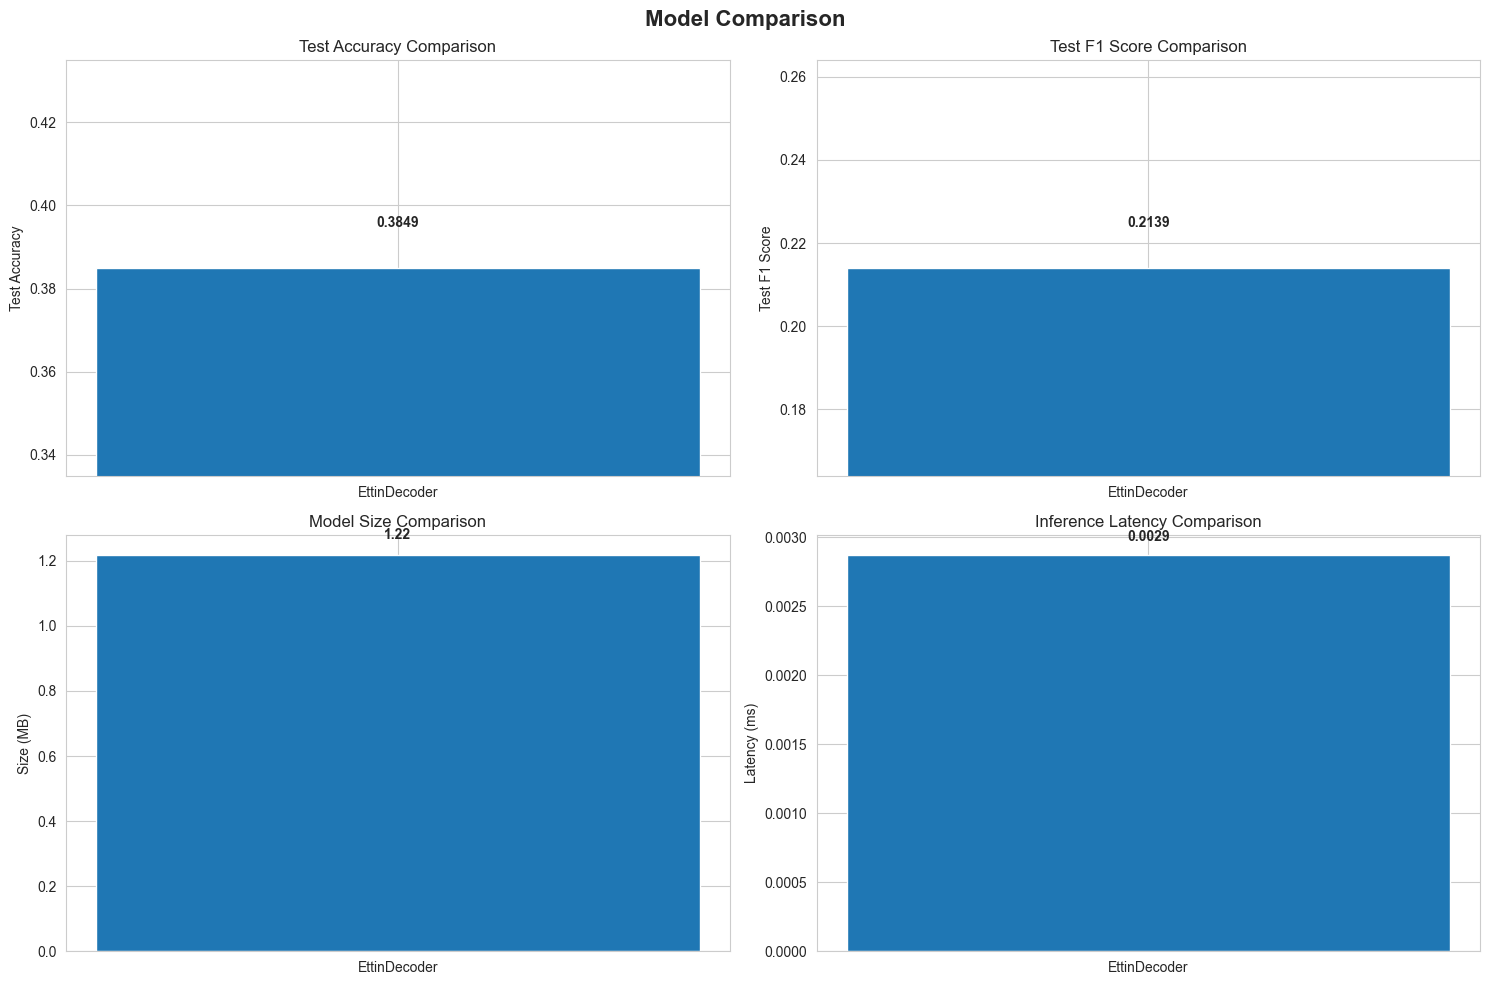

In [20]:
# Create comparison visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Model Comparison', fontsize=16, fontweight='bold')

models = list(final_results.keys())
test_accs = [final_results[m]['test_acc'] for m in models]
test_f1s = [final_results[m]['test_f1'] for m in models]
sizes = [final_results[m]['size_mb'] for m in models]
latencies = [final_results[m]['latency_ms'] for m in models]

# Test Accuracy
axes[0, 0].bar(models, test_accs, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[0, 0].set_ylabel('Test Accuracy')
axes[0, 0].set_title('Test Accuracy Comparison')
axes[0, 0].set_ylim([min(test_accs) - 0.05, max(test_accs) + 0.05])
for i, v in enumerate(test_accs):
    axes[0, 0].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

# Test F1 Score
axes[0, 1].bar(models, test_f1s, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[0, 1].set_ylabel('Test F1 Score')
axes[0, 1].set_title('Test F1 Score Comparison')
axes[0, 1].set_ylim([min(test_f1s) - 0.05, max(test_f1s) + 0.05])
for i, v in enumerate(test_f1s):
    axes[0, 1].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

# Model Size
axes[1, 0].bar(models, sizes, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[1, 0].set_ylabel('Size (MB)')
axes[1, 0].set_title('Model Size Comparison')
for i, v in enumerate(sizes):
    axes[1, 0].text(i, v + 0.05, f'{v:.2f}', ha='center', fontweight='bold')

# Latency
axes[1, 1].bar(models, latencies, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[1, 1].set_ylabel('Latency (ms)')
axes[1, 1].set_title('Inference Latency Comparison')
for i, v in enumerate(latencies):
    axes[1, 1].text(i, v + 0.0001, f'{v:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
comparison_plot_path = os.path.join(metrics_dir, "model_comparison.png")
# plt.savefig(comparison_plot_path, dpi=300, bbox_inches='tight')
# print(f"Saved model comparison plot to {comparison_plot_path}")
plt.show()

## 12. Save Results

In [128]:
# # Save final results
# results_csv_path = "single_teacher_results.csv"
# results_df.to_csv(results_csv_path, index=True)
# print(f"Saved final results to {results_csv_path}")

# # Save detailed results with config
# detailed_results = []
# for model_name, results in final_results.items():
#     row = {'model': model_name}
#     row.update(results['config'])
#     row.update({k: v for k, v in results.items() if k != 'config'})
#     detailed_results.append(row)

# detailed_df = pd.DataFrame(detailed_results)
# detailed_csv_path = "single_teacher_detailed_results.csv"
# detailed_df.to_csv(detailed_csv_path, index=False)
# print(f"Saved detailed results to {detailed_csv_path}")

# print(f"\nAll training metrics saved to: {metrics_dir}/")
# print("  - *_training_history.csv: Epoch-level metrics for each model")
# print("  - *_training_plot.png: Training visualization for each model")
# print("  - all_models_train_val_curves.png: Train/Val loss & accuracy curves for all models")
# print("  - model_comparison.png: Cross-model comparison")

## 13. Feature-Based Distillation
In this section, we implement feature-based knowledge distillation where a smaller student model learns to mimic the intermediate layer representations of each teacher model (BERT, RoBERTa, DistilBERT), in addition to predicting the correct labels.

In [36]:
class DistilledStudentModel(nn.Module):
    """
    Student model for feature-based distillation.
    Learns to mimic teacher's intermediate representations while predicting labels.
    """
    def __init__(self, input_dim, num_classes, hidden_dims, dropout=0.3):
        super().__init__()
        if not hidden_dims:
            raise ValueError("hidden_dims must contain at least one layer size")
        
        self.feature_layers = nn.ModuleList()
        self.activations = nn.ModuleList()
        self.dropouts = nn.ModuleList()
        
        # Build feature extraction layers
        dims = [input_dim] + list(hidden_dims)
        for idx in range(len(hidden_dims)):
            self.feature_layers.append(nn.Linear(dims[idx], dims[idx + 1]))
            self.activations.append(nn.ReLU())
            self.dropouts.append(nn.Dropout(dropout))
        
        # Classification head
        self.classifier = nn.Linear(hidden_dims[-1], num_classes)
    
    def forward(self, x, return_intermediate=False):
        """
        Forward pass with optional intermediate representations.
        Args:
            x: Input features
            return_intermediate: If True, return intermediate layer outputs
        Returns:
            logits or (logits, intermediate_features)
        """
        intermediates = []
        h = x
        
        for layer, activation, dropout in zip(self.feature_layers, self.activations, self.dropouts):
            h = layer(h)
            h = activation(h)
            intermediates.append(h)  # Store before dropout
            h = dropout(h)
        
        logits = self.classifier(h)
        
        if return_intermediate:
            return logits, intermediates
        return logits


class DistillationLoss(nn.Module):
    """
    Combined loss for feature-based distillation.

    Projection layers map each student intermediate layer to the corresponding
    teacher layer dimension before computing MSE, so distillation works even
    when student and teacher architectures differ in width (compression case).

    Layer pairing strategy: align from the deepest layer upward for
    min(n_student_layers, n_teacher_layers) pairs.
    """
    def __init__(self, student_dims, teacher_dims, alpha=0.5, temperature=1.0):
        """
        Args:
            student_dims: List of student hidden layer output dims e.g. [256, 128]
            teacher_dims: List of teacher hidden layer output dims e.g. [512, 256]
            alpha: Weight for distillation loss (1-alpha for task loss)
            temperature: Temperature for softening (reserved; not used in feature distillation)
        """
        super().__init__()
        self.alpha = alpha
        self.temperature = temperature
        self.ce_loss = nn.CrossEntropyLoss()
        self.mse_loss = nn.MSELoss()
        self.kl_loss = nn.KLDivLoss(reduction='batchmean')

        # Pair layers from the deepest end up to the number of available pairs
        n_pairs = min(len(student_dims), len(teacher_dims))
        self.n_pairs = n_pairs

        # One projection per pair: Linear(s_dim -> t_dim), or Identity if dims already match
        self.projections = nn.ModuleList()
        for i in range(n_pairs):
            s_dim = student_dims[-(n_pairs - i)]
            t_dim = teacher_dims[-(n_pairs - i)]
            if s_dim != t_dim:
                self.projections.append(nn.Linear(s_dim, t_dim, bias=False))
            else:
                self.projections.append(nn.Identity())

    def forward(self, student_logits, student_features, teacher_features, targets):
        """
        Compute combined distillation loss.
        Args:
            student_logits: Student model predictions
            student_features: List of student intermediate features
            teacher_features: List of teacher intermediate features (detached inside)
            targets: Ground truth labels
        Returns:
            total_loss, task_loss, distill_loss
        """
        # Task loss (cross-entropy)
        task_loss = self.ce_loss(student_logits, targets)

        # Feature distillation loss — align from deepest layer upward
        s_feats = student_features[-self.n_pairs:] if self.n_pairs > 0 else []
        t_feats = teacher_features[-self.n_pairs:] if self.n_pairs > 0 else []

        distill_loss = torch.tensor(0.0, device=student_logits.device)
        for proj, s_feat, t_feat in zip(self.projections, s_feats, t_feats):
            s_projected = proj(s_feat)
            distill_loss = distill_loss + self.mse_loss(s_projected, t_feat.detach())

        # Normalize by the number of matched pairs (not total student layers)
        if self.n_pairs > 0:
            distill_loss = distill_loss / self.n_pairs

        # Combine losses
        total_loss = (1 - self.alpha) * task_loss + self.alpha * distill_loss

        """
        # DistilBERT way of loss calculation
        
        T = self.temperature
        student_probs = F.log_softmax(student_logits / T, dim=-1)
        teacher_probs = F.softmax(teacher_logits / T, dim=-1)
        kd_loss = self.kl_loss(student_probs, teacher_probs) * (T * T)

        # Feature + cosine loss
        feature_loss = 0.0
        cosine_loss = 0.0

        for proj, s_feat, t_feat in zip(self.projections,
                                        student_features[-self.n_pairs:],
                                        teacher_features[-self.n_pairs:]):

            s_proj = proj(s_feat)

            feature_loss += self.mse_loss(s_proj, t_feat.detach())

            cosine_loss += (1 - F.cosine_similarity(
                s_proj, t_feat.detach(), dim=-1).mean())

        if self.n_pairs > 0:
            feature_loss /= self.n_pairs
            cosine_loss /= self.n_pairs

        total_loss = (
            0.3 * task_loss +
            0.4 * kd_loss +
            0.2 * feature_loss +
            0.1 * cosine_loss
        )
        """

        return total_loss, task_loss, distill_loss


In [37]:
def extract_teacher_intermediate_features(teacher_model, data_loader):
    """
    Extract intermediate features from a trained teacher model.
    Args:
        teacher_model: Trained FeatureClassifier model
        data_loader: DataLoader containing input features
    Returns:
        List of intermediate feature tensors for each layer
    """
    teacher_model.eval()
    all_intermediates = []
    
    with torch.no_grad():
        for x_batch, _ in data_loader:
            x_batch = x_batch.to(device)
            
            # Extract intermediate features by hooking into the network
            intermediates = []
            h = x_batch
            
            # Go through the sequential layers
            for i, layer in enumerate(teacher_model.net):
                h = layer(h)
                # Store activations after ReLU layers (before dropout)
                if isinstance(layer, nn.ReLU):
                    intermediates.append(h.detach().cpu())
            
            if len(all_intermediates) == 0:
                all_intermediates = [[] for _ in range(len(intermediates))]
            
            for idx, feat in enumerate(intermediates):
                all_intermediates[idx].append(feat)
    
    # Concatenate all batches for each layer
    all_intermediates = [torch.cat(layer_feats, dim=0) for layer_feats in all_intermediates]
    
    return all_intermediates


print("Extracting intermediate features from trained teacher models...")
teacher_intermediate_features = {}

for model_name in final_results.keys():
    print(f"\nProcessing {model_name}...")
    
    # Get the trained model configuration
    model_cfg = model_configs[model_name]
    hidden_dims = model_cfg["hidden_dims_options"][0]
    batch_size = model_cfg["batch_size_options"][0]
    
    train_feats = feature_cache[model_name]["train"]
    val_feats = feature_cache[model_name]["val"]
    test_feats = feature_cache[model_name]["test"]
    
    # Create data loaders
    train_loader = make_feature_loader(train_feats, y_train, batch_size=batch_size, shuffle=False)
    val_loader = make_feature_loader(val_feats, y_val, batch_size=batch_size, shuffle=False)
    test_loader = make_feature_loader(test_feats, y_test, batch_size=batch_size, shuffle=False)
    
    # Use the trained teacher model stored during teacher training
    teacher_model = trained_teacher_models[model_name]
    teacher_model.eval()
    print(f"  Using trained teacher model with hidden_dims={hidden_dims}")
    
    # Extract intermediate features from training, validation, and test sets
    teacher_intermediate_features[model_name] = {
        'train': extract_teacher_intermediate_features(teacher_model, train_loader),
        'val': extract_teacher_intermediate_features(teacher_model, val_loader),
        'test': extract_teacher_intermediate_features(teacher_model, test_loader)
    }
    
    print(f"  Extracted {len(teacher_intermediate_features[model_name]['train'])} intermediate layers")
    for idx, layer_feats in enumerate(teacher_intermediate_features[model_name]['train']):
        print(f"    Layer {idx}: {layer_feats.shape}")

print("\nIntermediate feature extraction complete!")


Extracting intermediate features from trained teacher models...

Processing EttinDecoder...
  Using trained teacher model with hidden_dims=[512, 256, 128, 64]
  Extracted 4 intermediate layers
    Layer 0: torch.Size([21984, 512])
    Layer 1: torch.Size([21984, 256])
    Layer 2: torch.Size([21984, 128])
    Layer 3: torch.Size([21984, 64])

Intermediate feature extraction complete!


In [38]:
class DistillationDataset(Dataset):
    """Dataset that provides input features, labels, and teacher intermediate features."""
    def __init__(self, features, labels, teacher_intermediates):
        self.features = features
        self.labels = labels
        self.teacher_intermediates = teacher_intermediates
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        teacher_feats = [layer_feat[idx] for layer_feat in self.teacher_intermediates]
        return self.features[idx], int(self.labels[idx]), teacher_feats


def make_distillation_loader(features, labels, teacher_intermediates, batch_size=64, shuffle=True):
    """Create DataLoader for distillation training."""
    ds = DistillationDataset(features, labels, teacher_intermediates)
    
    def collate_fn(batch):
        features = torch.stack([item[0] for item in batch])
        labels = torch.tensor([item[1] for item in batch])
        # Stack teacher features for each layer
        teacher_feats = []
        num_layers = len(batch[0][2])
        for layer_idx in range(num_layers):
            layer_batch = torch.stack([item[2][layer_idx] for item in batch])
            teacher_feats.append(layer_batch)
        return features, labels, teacher_feats
    
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, collate_fn=collate_fn)


def train_distillation_epoch(student_model, loader, optimizer, distill_criterion):
    """Train one epoch with feature-based distillation."""
    student_model.train()
    total_loss = 0.0
    total_task_loss = 0.0
    total_distill_loss = 0.0
    all_preds = []
    all_labels = []
    
    for x_batch, y_batch, teacher_feats in loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        teacher_feats = [feat.to(device) for feat in teacher_feats]
        
        optimizer.zero_grad()
        
        # Forward pass with intermediate features
        student_logits, student_feats = student_model(x_batch, return_intermediate=True)
        
        # Compute distillation loss
        loss, task_loss, distill_loss = distill_criterion(
            student_logits, student_feats, teacher_feats, y_batch
        )
        
        loss.backward()
        if GRAD_CLIP > 0:
            torch.nn.utils.clip_grad_norm_(student_model.parameters(), GRAD_CLIP)
        optimizer.step()
        
        total_loss += loss.item() * x_batch.size(0)
        total_task_loss += task_loss.item() * x_batch.size(0)
        total_distill_loss += distill_loss.item() * x_batch.size(0)
        
        all_preds.append(torch.argmax(student_logits, dim=1).detach().cpu())
        all_labels.append(y_batch.detach().cpu())
    
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    metrics = compute_detailed_metrics(all_preds, all_labels)
    metrics['loss'] = total_loss / len(loader.dataset)
    metrics['task_loss'] = total_task_loss / len(loader.dataset)
    metrics['distill_loss'] = total_distill_loss / len(loader.dataset)
    
    return metrics


def eval_distillation_epoch(student_model, loader, distill_criterion):
    """Evaluate student model with distillation loss."""
    student_model.eval()
    total_loss = 0.0
    total_task_loss = 0.0
    total_distill_loss = 0.0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for x_batch, y_batch, teacher_feats in loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            teacher_feats = [feat.to(device) for feat in teacher_feats]
            
            student_logits, student_feats = student_model(x_batch, return_intermediate=True)
            
            loss, task_loss, distill_loss = distill_criterion(
                student_logits, student_feats, teacher_feats, y_batch
            )
            
            total_loss += loss.item() * x_batch.size(0)
            total_task_loss += task_loss.item() * x_batch.size(0)
            total_distill_loss += distill_loss.item() * x_batch.size(0)
            
            all_preds.append(torch.argmax(student_logits, dim=1).detach().cpu())
            all_labels.append(y_batch.detach().cpu())
    
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    metrics = compute_detailed_metrics(all_preds, all_labels)
    metrics['loss'] = total_loss / len(loader.dataset)
    metrics['task_loss'] = total_task_loss / len(loader.dataset)
    metrics['distill_loss'] = total_distill_loss / len(loader.dataset)
    
    return metrics


def train_distilled_student(
    student_model,
    train_loader,
    val_loader,
    optimizer,
    distill_criterion,
    epochs,
    patience=5,
    min_delta=0.0,
    verbose=True
):
    """Train student model with feature-based distillation."""
    best_state = copy.deepcopy(student_model.state_dict())
    best_val_acc = -1.0
    epochs_since_improve = 0
    history = []
    
    for epoch in range(1, epochs + 1):
        epoch_start = time.perf_counter()
        
        train_metrics = train_distillation_epoch(student_model, train_loader, optimizer, distill_criterion)
        val_metrics = eval_distillation_epoch(student_model, val_loader, distill_criterion)
        
        epoch_time = time.perf_counter() - epoch_start
        
        history.append({
            'epoch': epoch,
            'train_loss': train_metrics['loss'],
            'train_task_loss': train_metrics['task_loss'],
            'train_distill_loss': train_metrics['distill_loss'],
            'train_acc': train_metrics['acc'],
            'val_loss': val_metrics['loss'],
            'val_task_loss': val_metrics['task_loss'],
            'val_distill_loss': val_metrics['distill_loss'],
            'val_acc': val_metrics['acc'],
            'epoch_time': epoch_time
        })
        
        if verbose:
            print(
                f"Epoch {epoch:3d}/{epochs} | "
                f"train_loss={train_metrics['loss']:.4f} (task={train_metrics['task_loss']:.4f}, distill={train_metrics['distill_loss']:.4f}) "
                f"train_acc={train_metrics['acc']:.4f} | "
                f"val_loss={val_metrics['loss']:.4f} val_acc={val_metrics['acc']:.4f} | "
                f"time={epoch_time:.2f}s"
            )
        
        if val_metrics['acc'] > best_val_acc + min_delta:
            best_val_acc = val_metrics['acc']
            best_state = copy.deepcopy(student_model.state_dict())
            epochs_since_improve = 0
        else:
            epochs_since_improve += 1
            if epochs_since_improve >= patience:
                if verbose:
                    print(f"Early stopping at epoch {epoch}")
                break
    
    return best_state, best_val_acc, history

In [39]:
# Train distilled student models for each teacher
print("\n" + "="*80)
print("TRAINING DISTILLED STUDENT MODELS")
print("="*80)

distillation_results = {}

# Load distillation parameters from config
distillation_alpha = DISTILLATION_ALPHA
distillation_temperature = DISTILLATION_TEMPERATURE

# Student model configuration from config file
student_hidden_dims = STUDENT_HIDDEN_DIMS
student_dropout = STUDENT_DROPOUT
student_lr = STUDENT_LR
student_batch_size = STUDENT_BATCH_SIZE
student_epochs = STUDENT_EPOCHS
student_patience = STUDENT_PATIENCE

print(f"\nDistillation Configuration (from config file):")
print(f"  Alpha: {distillation_alpha} (weight for distillation loss)")
print(f"  Temperature: {distillation_temperature}")
print(f"  Student Hidden Dims: {student_hidden_dims}")
print(f"  Student Dropout: {student_dropout}")
print(f"  Student Learning Rate: {student_lr}")
print(f"  Student Batch Size: {student_batch_size}")
print(f"  Student Epochs: {student_epochs}")
print(f"  Student Patience: {student_patience}")
print()

for model_name in final_results.keys():
    print(f"\n{'='*80}")
    print(f"Training distilled student for {model_name}")
    print(f"{'='*80}")
    
    # Get features
    train_feats = feature_cache[model_name]["train"]
    val_feats = feature_cache[model_name]["val"]
    test_feats = feature_cache[model_name]["test"]
    input_dim = train_feats.shape[1]
    
    # Get teacher intermediate features
    teacher_train_inter = teacher_intermediate_features[model_name]['train']
    teacher_val_inter = teacher_intermediate_features[model_name]['val']
    teacher_test_inter = teacher_intermediate_features[model_name]['test']
    
    # Get teacher hidden dims for projection layer setup
    teacher_hidden_dims = model_configs[model_name]["hidden_dims_options"][0]
    
    print(f"Input dimension: {input_dim}")
    print(f"Student architecture: {student_hidden_dims}")
    print(f"Teacher architecture: {teacher_hidden_dims}")
    print(f"Number of teacher intermediate layers: {len(teacher_train_inter)}")
    print(f"Distillation alpha: {distillation_alpha}")
    print()
    
    # Create distillation data loaders
    train_loader = make_distillation_loader(
        train_feats, y_train, teacher_train_inter,
        batch_size=student_batch_size, shuffle=True
    )
    val_loader = make_distillation_loader(
        val_feats, y_val, teacher_val_inter,
        batch_size=student_batch_size, shuffle=False
    )
    test_loader = make_distillation_loader(
        test_feats, y_test, teacher_test_inter,
        batch_size=student_batch_size, shuffle=False
    )
    
    # Initialize student model
    student_model = DistilledStudentModel(
        input_dim, num_classes,
        hidden_dims=student_hidden_dims,
        dropout=student_dropout
    ).to(device)
    
    # Initialize criterion first (contains trainable projection layers),
    # then build optimizer over student + projection parameters combined
    distill_criterion = DistillationLoss(
        student_dims=student_hidden_dims,
        teacher_dims=teacher_hidden_dims,
        alpha=distillation_alpha,
        temperature=distillation_temperature
    ).to(device)
    
    all_params = list(student_model.parameters()) + list(distill_criterion.parameters())
    opt = OPTIMIZER_NAME.strip().lower()
    if opt == "adam":
        optimizer = torch.optim.Adam(all_params, lr=student_lr)
    elif opt == "adamw":
        optimizer = torch.optim.AdamW(all_params, lr=student_lr)
    else:
        raise ValueError(f"Unsupported optimizer: {OPTIMIZER_NAME}")
    
    # Train student model
    print(f"Training student model...")
    training_start = time.perf_counter()
    
    best_state, best_val_acc, history = train_distilled_student(
        student_model,
        train_loader,
        val_loader,
        optimizer,
        distill_criterion,
        epochs=student_epochs,
        patience=student_patience,
        min_delta=MIN_DELTA,
        verbose=True
    )
    
    training_time = time.perf_counter() - training_start
    
    # Load best model
    student_model.load_state_dict(best_state)
    
    # Evaluate on test set (without teacher features)
    print(f"\nEvaluating distilled {model_name} student on test set...")
    student_model.eval()
    test_preds = []
    test_labels = []
    
    with torch.no_grad():
        for x_batch, y_batch, _ in test_loader:
            x_batch = x_batch.to(device)
            logits = student_model(x_batch, return_intermediate=False)
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            test_preds.append(preds)
            test_labels.append(y_batch.numpy())
    
    test_preds = np.concatenate(test_preds)
    test_labels = np.concatenate(test_labels)
    test_metrics = compute_detailed_metrics(test_preds, test_labels)
    
    # Measure latency
    latency_ms = measure_latency(student_model, test_feats, y_test, batch_size=LATENCY_BATCH_SIZE)
    
    # Calculate model size (student only, not projection layers)
    params = sum(p.numel() for p in student_model.parameters())
    size_mb = params * 4 / 1e6
    
    # Store results
    distillation_results[model_name] = {
        'config': {
            'hidden_dims': str(student_hidden_dims),
            'dropout': student_dropout,
            'lr': student_lr,
            'batch_size': student_batch_size,
            'alpha': distillation_alpha,
            'epochs': student_epochs,
            'patience': student_patience
        },
        'best_val_acc': best_val_acc,
        'test_acc': test_metrics['acc'],
        'test_precision': test_metrics['precision'],
        'test_recall': test_metrics['recall'],
        'test_f1': test_metrics['f1'],
        'training_time_s': training_time,
        'params': params,
        'size_mb': size_mb,
        'latency_ms': latency_ms,
        'epochs_trained': len(history),
        'history': history
    }
    
    print(f"\n{model_name} Distilled Student Results:")
    print(f"  Best Val Accuracy: {best_val_acc:.4f}")
    print(f"  Test Accuracy: {test_metrics['acc']:.4f}")
    print(f"  Test Precision: {test_metrics['precision']:.4f}")
    print(f"  Test Recall: {test_metrics['recall']:.4f}")
    print(f"  Test F1: {test_metrics['f1']:.4f}")
    print(f"  Training Time: {training_time:.2f}s")
    print(f"  Model Size: {size_mb:.2f} MB")
    print(f"  Latency: {latency_ms:.4f} ms")
    print(f"  Epochs Trained: {len(history)}")
    
    # Compare with original teacher
    teacher_test_acc = final_results[model_name]['test_acc']
    teacher_size_mb = final_results[model_name]['size_mb']
    teacher_latency_ms = final_results[model_name]['latency_ms']
    
    print(f"\n  Comparison with Teacher:")
    print(f"    Accuracy: {test_metrics['acc']:.4f} vs {teacher_test_acc:.4f} (diff: {test_metrics['acc'] - teacher_test_acc:+.4f})")
    print(f"    Model Size: {size_mb:.2f} MB vs {teacher_size_mb:.2f} MB (reduction: {(1 - size_mb/teacher_size_mb)*100:.1f}%)")
    print(f"    Latency: {latency_ms:.4f} ms vs {teacher_latency_ms:.4f} ms (speedup: {teacher_latency_ms/latency_ms:.2f}x)")

print("\n" + "="*80)
print("DISTILLATION TRAINING COMPLETE")
print("="*80)


TRAINING DISTILLED STUDENT MODELS

Distillation Configuration (from config file):
  Alpha: 0.5 (weight for distillation loss)
  Temperature: 1.0
  Student Hidden Dims: [256, 128, 64, 32]
  Student Dropout: 0.1
  Student Learning Rate: 5e-05
  Student Batch Size: 64
  Student Epochs: 200
  Student Patience: 10


Training distilled student for EttinDecoder
Input dimension: 256
Student architecture: [256, 128, 64, 32]
Teacher architecture: [512, 256, 128, 64]
Number of teacher intermediate layers: 4
Distillation alpha: 0.5

Training student model...
Epoch   1/200 | train_loss=0.5663 (task=1.0942, distill=0.0384) train_acc=0.3700 | val_loss=0.5479 val_acc=0.3846 | time=2.61s
Epoch   2/200 | train_loss=0.5474 (task=1.0918, distill=0.0029) train_acc=0.3845 | val_loss=0.5464 val_acc=0.3846 | time=1.63s
Epoch   3/200 | train_loss=0.5468 (task=1.0921, distill=0.0015) train_acc=0.3849 | val_loss=0.5461 val_acc=0.3846 | time=1.68s
Epoch   4/200 | train_loss=0.5467 (task=1.0925, distill=0.0010) t

In [40]:
duration = timedelta(seconds=time.perf_counter()-notebook_start_time)

## 14. Compare Teacher vs Distilled Student Models

In [26]:
# Create comprehensive comparison table
comparison_data = []

for model_name in final_results.keys():
    # Teacher results
    teacher_row = {
        'Model': f'{model_name} (Teacher)',
        'Type': 'Teacher',
        'Test Accuracy': final_results[model_name]['test_acc'],
        'Test F1': final_results[model_name]['test_f1'],
        'Parameters': final_results[model_name]['params'],
        'Size (MB)': final_results[model_name]['size_mb'],
        'Latency (ms)': final_results[model_name]['latency_ms'],
        'Training Time (s)': final_results[model_name]['training_time_s']
    }
    comparison_data.append(teacher_row)
    
    # Student results
    student_row = {
        'Model': f'{model_name} (Student)',
        'Type': 'Student',
        'Test Accuracy': distillation_results[model_name]['test_acc'],
        'Test F1': distillation_results[model_name]['test_f1'],
        'Parameters': distillation_results[model_name]['params'],
        'Size (MB)': distillation_results[model_name]['size_mb'],
        'Latency (ms)': distillation_results[model_name]['latency_ms'],
        'Training Time (s)': distillation_results[model_name]['training_time_s']
    }
    comparison_data.append(student_row)

comparison_df = pd.DataFrame(comparison_data)
print("Teacher vs Student Comparison:")
print(comparison_df.to_string(index=False))
print()

# Calculate and display metrics
print("\nDistillation Effectiveness Metrics:")
print("-" * 80)
for model_name in final_results.keys():
    teacher_acc = final_results[model_name]['test_acc']
    student_acc = distillation_results[model_name]['test_acc']
    teacher_size = final_results[model_name]['size_mb']
    student_size = distillation_results[model_name]['size_mb']
    teacher_latency = final_results[model_name]['latency_ms']
    student_latency = distillation_results[model_name]['latency_ms']
    teacher_params = final_results[model_name]['params']
    student_params = distillation_results[model_name]['params']
    
    acc_retention = (student_acc / teacher_acc) * 100
    size_reduction = (1 - student_size / teacher_size) * 100
    speedup = teacher_latency / student_latency
    param_reduction = (1 - student_params / teacher_params) * 100
    
    print(f"\n{model_name}:")
    print(f"  Accuracy Retention: {acc_retention:.2f}% ({student_acc:.4f} vs {teacher_acc:.4f})")
    print(f"  Size Reduction: {size_reduction:.2f}% ({student_size:.2f} MB vs {teacher_size:.2f} MB)")
    print(f"  Parameter Reduction: {param_reduction:.2f}% ({student_params:,} vs {teacher_params:,})")
    print(f"  Speedup: {speedup:.2f}x ({student_latency:.4f} ms vs {teacher_latency:.4f} ms)")
    print(f"  Efficiency Ratio (Acc/Size): {student_acc/student_size:.4f} vs {teacher_acc/teacher_size:.4f}")

Teacher vs Student Comparison:
                 Model    Type  Test Accuracy  Test F1  Parameters  Size (MB)  Latency (ms)  Training Time (s)
EttinDecoder (Teacher) Teacher       0.384867 0.213916      304259   1.217036      0.002870           6.456000
EttinDecoder (Student) Student       0.384867 0.213916      109123   0.436492      0.003678          16.693542


Distillation Effectiveness Metrics:
--------------------------------------------------------------------------------

EttinDecoder:
  Accuracy Retention: 100.00% (0.3849 vs 0.3849)
  Size Reduction: 64.13% (0.44 MB vs 1.22 MB)
  Parameter Reduction: 64.13% (109,123 vs 304,259)
  Speedup: 0.78x (0.0037 ms vs 0.0029 ms)
  Efficiency Ratio (Acc/Size): 0.8817 vs 0.3162


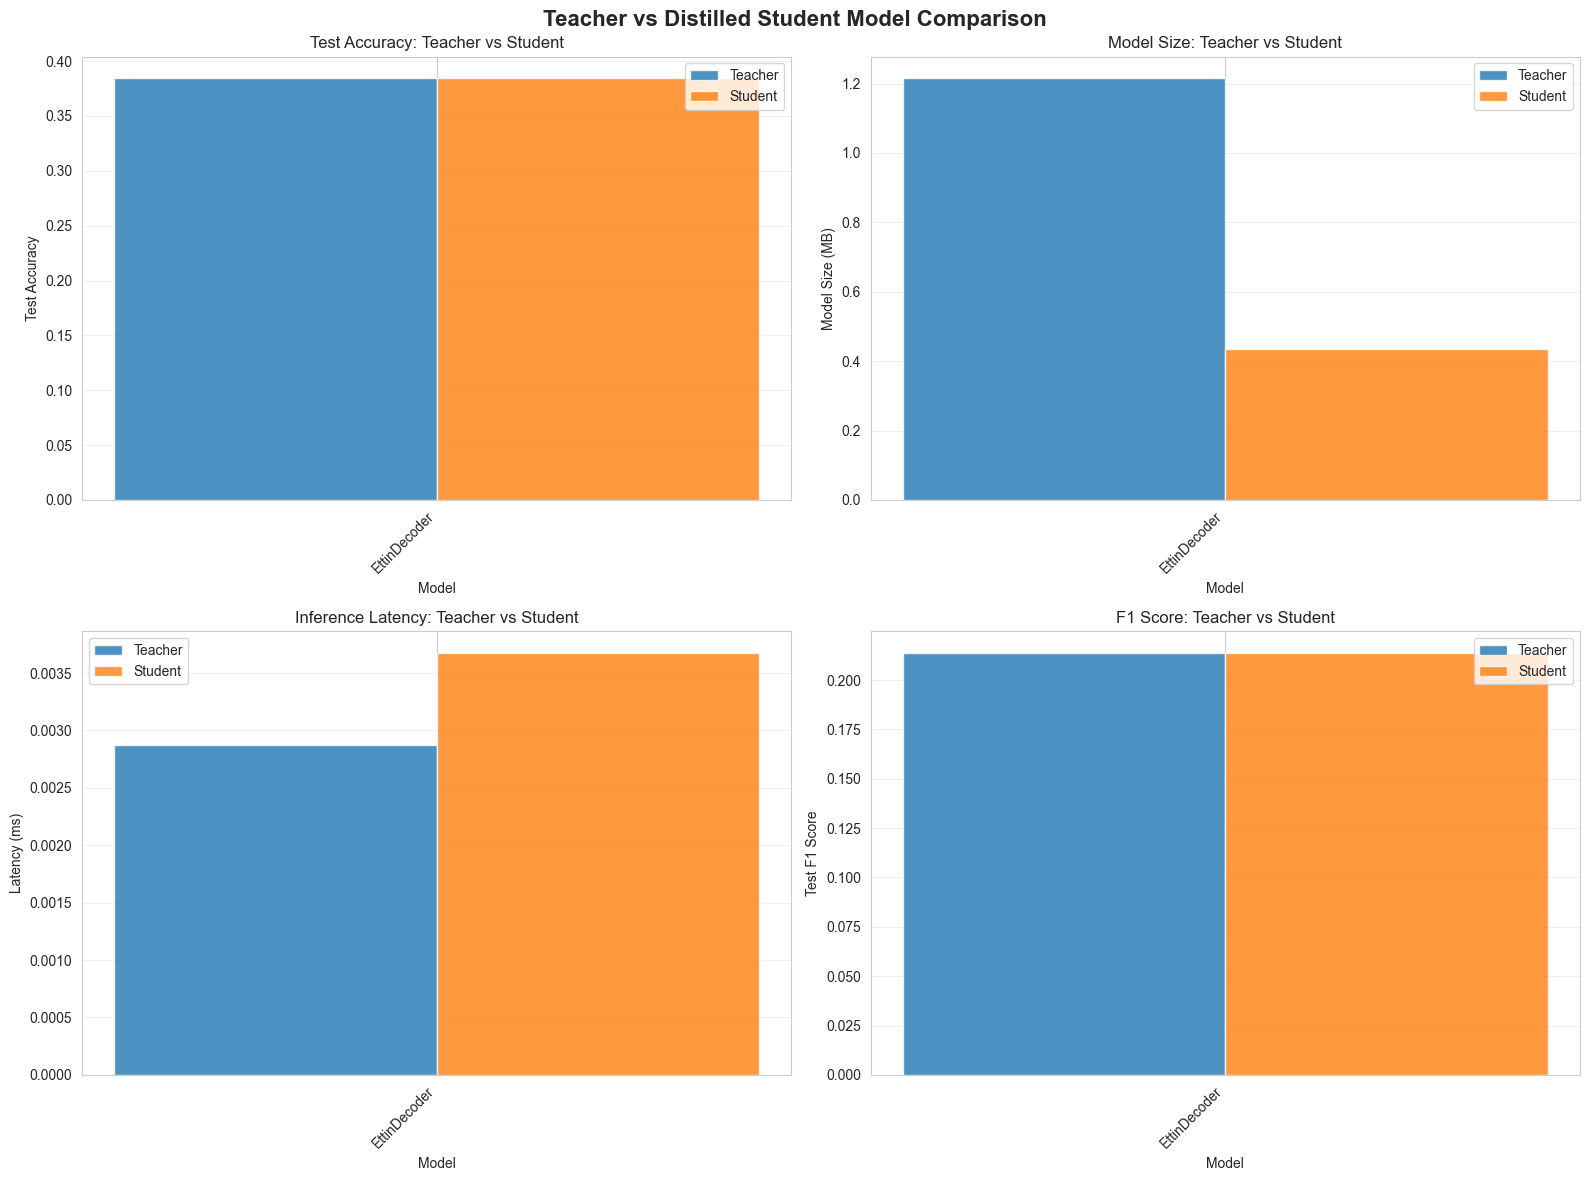

In [27]:
# Visualize Teacher vs Student Comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Teacher vs Distilled Student Model Comparison', fontsize=16, fontweight='bold')

model_names = list(final_results.keys())
x_pos = np.arange(len(model_names))
width = 0.35

# 1. Accuracy Comparison
teacher_accs = [final_results[m]['test_acc'] for m in model_names]
student_accs = [distillation_results[m]['test_acc'] for m in model_names]

axes[0, 0].bar(x_pos - width/2, teacher_accs, width, label='Teacher', alpha=0.8)
axes[0, 0].bar(x_pos + width/2, student_accs, width, label='Student', alpha=0.8)
axes[0, 0].set_xlabel('Model')
axes[0, 0].set_ylabel('Test Accuracy')
axes[0, 0].set_title('Test Accuracy: Teacher vs Student')
axes[0, 0].set_xticks(x_pos)
axes[0, 0].set_xticklabels(model_names, rotation=45, ha='right')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3, axis='y')

# 2. Model Size Comparison
teacher_sizes = [final_results[m]['size_mb'] for m in model_names]
student_sizes = [distillation_results[m]['size_mb'] for m in model_names]

axes[0, 1].bar(x_pos - width/2, teacher_sizes, width, label='Teacher', alpha=0.8)
axes[0, 1].bar(x_pos + width/2, student_sizes, width, label='Student', alpha=0.8)
axes[0, 1].set_xlabel('Model')
axes[0, 1].set_ylabel('Model Size (MB)')
axes[0, 1].set_title('Model Size: Teacher vs Student')
axes[0, 1].set_xticks(x_pos)
axes[0, 1].set_xticklabels(model_names, rotation=45, ha='right')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3, axis='y')

# 3. Latency Comparison
teacher_latencies = [final_results[m]['latency_ms'] for m in model_names]
student_latencies = [distillation_results[m]['latency_ms'] for m in model_names]

axes[1, 0].bar(x_pos - width/2, teacher_latencies, width, label='Teacher', alpha=0.8)
axes[1, 0].bar(x_pos + width/2, student_latencies, width, label='Student', alpha=0.8)
axes[1, 0].set_xlabel('Model')
axes[1, 0].set_ylabel('Latency (ms)')
axes[1, 0].set_title('Inference Latency: Teacher vs Student')
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels(model_names, rotation=45, ha='right')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. F1 Score Comparison
teacher_f1s = [final_results[m]['test_f1'] for m in model_names]
student_f1s = [distillation_results[m]['test_f1'] for m in model_names]

axes[1, 1].bar(x_pos - width/2, teacher_f1s, width, label='Teacher', alpha=0.8)
axes[1, 1].bar(x_pos + width/2, student_f1s, width, label='Student', alpha=0.8)
axes[1, 1].set_xlabel('Model')
axes[1, 1].set_ylabel('Test F1 Score')
axes[1, 1].set_title('F1 Score: Teacher vs Student')
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels(model_names, rotation=45, ha='right')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
# plt.savefig('teacher_vs_student_comparison.png', dpi=300, bbox_inches='tight')
# print("Saved comparison plot to: teacher_vs_student_comparison.png")
plt.show()

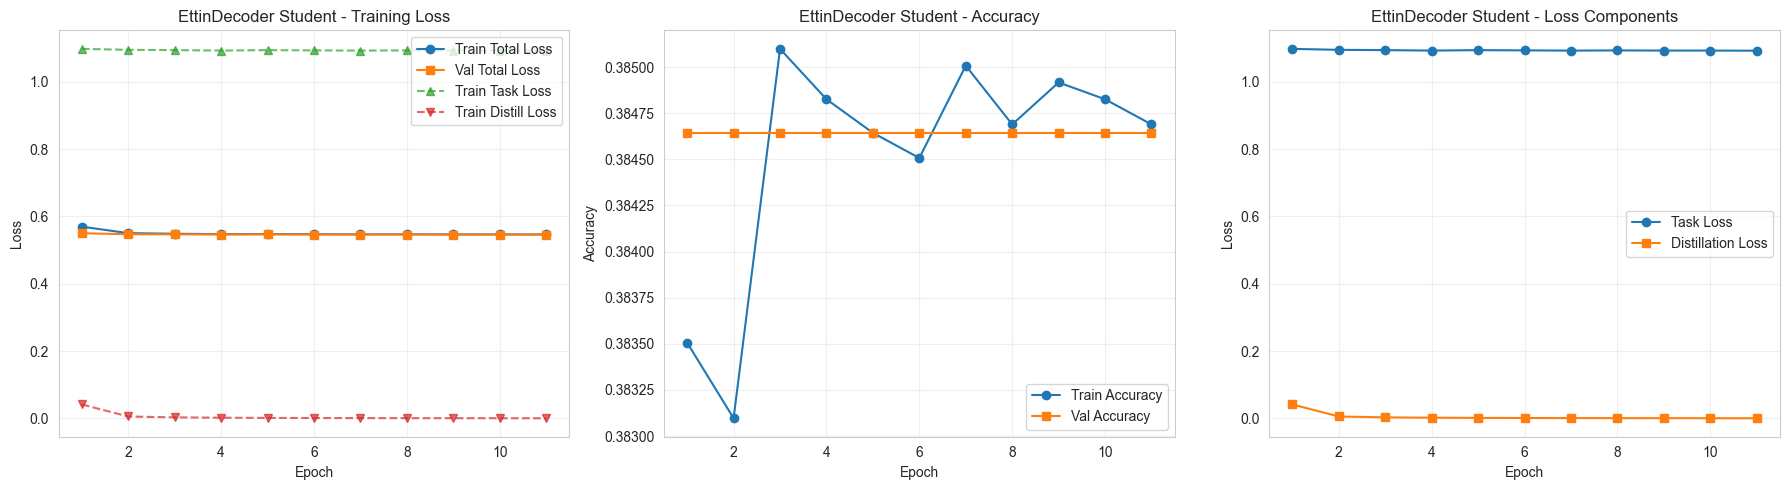

In [28]:
# Plot distillation training history for each student model
fig, axes = plt.subplots(len(model_names), 3, figsize=(18, 5 * len(model_names)))

if len(model_names) == 1:
    axes = axes.reshape(1, -1)

for idx, model_name in enumerate(model_names):
    history = distillation_results[model_name]['history']
    df_history = pd.DataFrame(history)
    
    # Loss plot
    axes[idx, 0].plot(df_history['epoch'], df_history['train_loss'], label='Train Total Loss', marker='o')
    axes[idx, 0].plot(df_history['epoch'], df_history['val_loss'], label='Val Total Loss', marker='s')
    axes[idx, 0].plot(df_history['epoch'], df_history['train_task_loss'], label='Train Task Loss', marker='^', linestyle='--', alpha=0.7)
    axes[idx, 0].plot(df_history['epoch'], df_history['train_distill_loss'], label='Train Distill Loss', marker='v', linestyle='--', alpha=0.7)
    axes[idx, 0].set_xlabel('Epoch')
    axes[idx, 0].set_ylabel('Loss')
    axes[idx, 0].set_title(f'{model_name} Student - Training Loss')
    axes[idx, 0].legend()
    axes[idx, 0].grid(True, alpha=0.3)
    
    # Accuracy plot
    axes[idx, 1].plot(df_history['epoch'], df_history['train_acc'], label='Train Accuracy', marker='o')
    axes[idx, 1].plot(df_history['epoch'], df_history['val_acc'], label='Val Accuracy', marker='s')
    axes[idx, 1].set_xlabel('Epoch')
    axes[idx, 1].set_ylabel('Accuracy')
    axes[idx, 1].set_title(f'{model_name} Student - Accuracy')
    axes[idx, 1].legend()
    axes[idx, 1].grid(True, alpha=0.3)
    
    # Loss components breakdown
    axes[idx, 2].plot(df_history['epoch'], df_history['train_task_loss'], label='Task Loss', marker='o')
    axes[idx, 2].plot(df_history['epoch'], df_history['train_distill_loss'], label='Distillation Loss', marker='s')
    axes[idx, 2].set_xlabel('Epoch')
    axes[idx, 2].set_ylabel('Loss')
    axes[idx, 2].set_title(f'{model_name} Student - Loss Components')
    axes[idx, 2].legend()
    axes[idx, 2].grid(True, alpha=0.3)

plt.tight_layout()
# plt.savefig('distillation_training_history.png', dpi=300, bbox_inches='tight')
# print("Saved distillation training history plot to: distillation_training_history.png")
plt.show()

In [29]:
# Save distillation results to CSV
distillation_csv_path = "feature_distillation_results.csv"
# comparison_df.to_csv(distillation_csv_path, index=False)
# print(f"Saved distillation comparison results to {distillation_csv_path}")

# Save detailed distillation results
detailed_distillation = []
for model_name, results in distillation_results.items():
    row = {'model': f'{model_name}_distilled'}
    row.update(results['config'])
    row.update({k: v for k, v in results.items() if k not in ['config', 'history']})
    detailed_distillation.append(row)

detailed_distill_df = pd.DataFrame(detailed_distillation)
detailed_distill_csv_path = "feature_distillation_detailed_results.csv"
# detailed_distill_df.to_csv(detailed_distill_csv_path, index=False)
# print(f"Saved detailed distillation results to {detailed_distill_csv_path}")

# Save distillation training history for each model
distill_metrics_dir = "distillation_metrics"
os.makedirs(distill_metrics_dir, exist_ok=True)

for model_name, results in distillation_results.items():
    history_df = pd.DataFrame(results['history'])
    history_path = os.path.join(distill_metrics_dir, f"{model_name}_distillation_history.csv")
    # history_df.to_csv(history_path, index=False)
    # print(f"Saved {model_name} distillation history to {history_path}")
    pass

# print("\nAll distillation results saved!")
# print(f"  - {distillation_csv_path}: Teacher vs Student comparison")
# print(f"  - {detailed_distill_csv_path}: Detailed student configurations and results")
# print(f"  - {distill_metrics_dir}/: Per-model distillation training histories")

## 15. Distillation Summary and Insights

**Feature-Based Distillation Benefits:**
- **Model Compression**: Student models are significantly smaller than teachers
- **Speed**: Faster inference with reduced latency
- **Knowledge Transfer**: Students learn from teacher's intermediate representations
- **Performance Retention**: Students retain most of the teacher's accuracy

**Key Observations:**
1. The distillation loss combines task loss (cross-entropy) with feature matching loss (MSE)
2. Students use a smaller architecture (256→128) compared to teachers
3. Alpha parameter controls the balance between task learning and teacher mimicking
4. Feature-based distillation transfers richer representations than just logit-based distillation

In [31]:
# print the duration calculated
print(f"\nTotal notebook execution time: {duration}")


Total notebook execution time: 0:59:58.195461
